# NIH ChestX-ray14 Dataset Analysis

## Overview

The **NIH ChestX-ray14** dataset is a large-scale collection of chest X-ray images with disease annotations, released by the National Institutes of Health. It contains over 100,000 X-ray images from more than 30,000 unique patients. Disease labels were extracted from radiology reports using natural language processing (NLP).

The dataset includes 14 disease categories (plus "No Finding") and uses a **multi-label** classification scheme — a single X-ray image can carry multiple disease labels.

## Purpose of This EDA

This exploratory data analysis examines the NIH ChestX-ray14 dataset to understand its basic characteristics, data structure, labels, class distributions, and image metadata. The findings provide the context needed for cross-domain pneumonia classification research, where this dataset is compared against other chest X-ray datasets (CheXpert and Kaggle Pediatric Pneumonia).


---

## 1. Imports and Setup

The required libraries for this analysis are imported below.


In [194]:
import kagglehub
from kagglehub import KaggleDatasetAdapter


---

## 2. Dataset Loading

The dataset metadata is loaded from `Data_Entry_2017.csv` using KaggleHub. This CSV contains image-level metadata: image file names, disease labels, patient information, image dimensions, and pixel spacing. The shape and first five records are displayed to confirm successful loading.


In [195]:
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "nih-chest-xrays/data",
    "Data_Entry_2017.csv"
)

print(df.shape)
print(df.head())

(112120, 12)
        Image Index          Finding Labels  Follow-up #  Patient ID  \
0  00000001_000.png            Cardiomegaly            0           1   
1  00000001_001.png  Cardiomegaly|Emphysema            1           1   
2  00000001_002.png   Cardiomegaly|Effusion            2           1   
3  00000002_000.png              No Finding            0           2   
4  00000003_000.png                  Hernia            0           3   

   Patient Age Patient Gender View Position  OriginalImage[Width  Height]  \
0           58              M            PA                 2682     2749   
1           58              M            PA                 2894     2729   
2           58              M            PA                 2500     2048   
3           81              M            PA                 2500     2048   
4           81              F            PA                 2582     2991   

   OriginalImagePixelSpacing[x     y]  Unnamed: 11  
0                        0.143  0.143 

---

## 3. Dataset Structure

We examine the column names, data types, and missing values. The dataset contains **12 columns** and **112,120 rows**.

**Column interpretation:**
- `Image Index` – X-ray image filename (primary identifier)
- `Finding Labels` – pipe-separated (`|`) disease annotation(s)
- `Follow-up #` – scan sequence number for the patient (0 = initial scan)
- `Patient ID` – unique patient identifier
- `Patient Age` – age in years
- `Patient Gender` – M / F
- `View Position` – PA / AP acquisition view
- `OriginalImage[Width`, `Height]` – original image dimensions in pixels
- `OriginalImagePixelSpacing[x`, `y]` – physical pixel spacing in mm
- `Unnamed: 11` – entirely empty column (CSV parsing artifact)

**Interpretation:** No missing values exist in any meaningful column. Only the artifact column `Unnamed: 11` is fully empty (112,120 missing values).


In [196]:
print ("Dataset Shape:",df.shape)
print(("\nColumns"))
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Value")
print(df.isnull().sum())


Dataset Shape: (112120, 12)

Columns
['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']

Data Types:
Image Index                     object
Finding Labels                  object
Follow-up #                      int64
Patient ID                       int64
Patient Age                      int64
Patient Gender                  object
View Position                   object
OriginalImage[Width              int64
Height]                          int64
OriginalImagePixelSpacing[x    float64
y]                             float64
Unnamed: 11                    float64
dtype: object

Missing Value
Image Index                         0
Finding Labels                      0
Follow-up #                         0
Patient ID                          0
Patient Age                         0
Patient Gender                      0
View Position             

---

## 4. Label Analysis

NIH ChestX-ray14 is a **multi-label** dataset: a single image can be annotated with zero, one, or several diseases simultaneously. Within the `Finding Labels` column, multiple diseases are joined with a pipe (`|`).

We examine two views of the labels:
1. **Label combinations** – the exact multi-label strings present in the data
2. **Individual disease frequencies** – obtained by splitting combinations on `|` and counting each disease separately


In [197]:
label_counts=df["Finding Labels"].value_counts()
print(label_counts.head(20))


Finding Labels
No Finding                           60361
Infiltration                          9547
Atelectasis                           4215
Effusion                              3955
Nodule                                2705
Pneumothorax                          2194
Mass                                  2139
Effusion|Infiltration                 1603
Atelectasis|Infiltration              1350
Consolidation                         1310
Atelectasis|Effusion                  1165
Pleural_Thickening                    1126
Cardiomegaly                          1093
Emphysema                              892
Infiltration|Nodule                    829
Atelectasis|Effusion|Infiltration      737
Fibrosis                               727
Edema                                  628
Cardiomegaly|Effusion                  484
Consolidation|Infiltration             441
Name: count, dtype: int64


In [198]:
indivisual_labels=df["Finding Labels"].str.split("|").explode()
label_distribution=indivisual_labels.value_counts()
print(label_distribution)

Finding Labels
No Finding            60361
Infiltration          19894
Effusion              13317
Atelectasis           11559
Nodule                 6331
Mass                   5782
Pneumothorax           5302
Consolidation          4667
Pleural_Thickening     3385
Cardiomegaly           2776
Emphysema              2516
Edema                  2303
Fibrosis               1686
Pneumonia              1431
Hernia                  227
Name: count, dtype: int64


---

## 5. Pneumonia Analysis

For the pneumonia classification task, an image is treated as **pneumonia-positive** if "Pneumonia" appears anywhere in its labels (either alone or combined with other diseases); all remaining images are **pneumonia-negative**.

> **Key observation:** This split creates a severe class imbalance, which is a central challenge for pneumonia classification.


In [199]:
pneumonia_positive = df["Finding Labels"].str.contains(
    "Pneumonia", 
    case=False, 
    na=False
)

print("Pneumonia-positive images:", pneumonia_positive.sum())
print("Pneumonia-negative images:", (~pneumonia_positive).sum())

Pneumonia-positive images: 1431
Pneumonia-negative images: 110689


In [200]:
total = len(df)

pneumonia_percentage = (pneumonia_positive.sum() / total) * 100
negative_percentage = ((~pneumonia_positive).sum() / total) * 100

print(f"Pneumonia-positive: {pneumonia_percentage:.2f}%")
print(f"Pneumonia-negative: {negative_percentage:.2f}%")

Pneumonia-positive: 1.28%
Pneumonia-negative: 98.72%


### Pneumonia Class Distribution

The bar chart below visualizes the pneumonia-positive versus pneumonia-negative split, making the extreme class imbalance immediately visible.


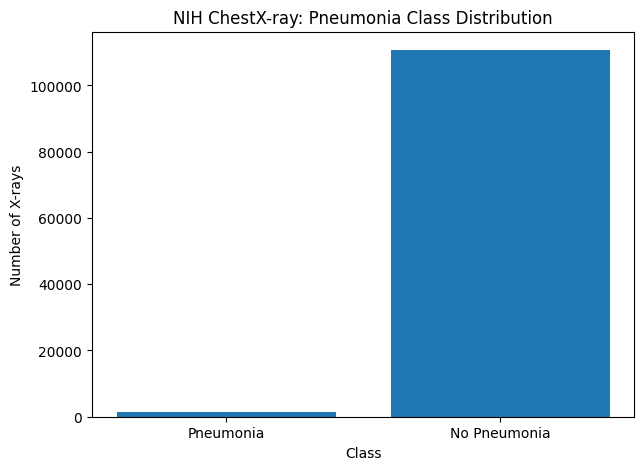

In [201]:
import matplotlib.pyplot as plt

labels = ["Pneumonia", "No Pneumonia"]
counts = [pneumonia_positive.sum(), (~pneumonia_positive).sum()]

plt.figure(figsize=(7, 5))
plt.bar(labels, counts)

plt.title("NIH ChestX-ray: Pneumonia Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of X-rays")

plt.show()

---

## 6. Patient-Level Analysis

The dataset contains multiple X-ray images per patient in the form of follow-up scans. Understanding the patient-level structure is essential for correct train/test splitting, because images from the same patient must not be split across training and test sets (data leakage).


In [202]:
unique_patients = df["Patient ID"].nunique()

print("Total X-ray images:", len(df))
print("Unique patients:", unique_patients)

Total X-ray images: 112120
Unique patients: 30805


In [203]:
images_per_patient = df["Patient ID"].value_counts()

print(images_per_patient.describe())


count    30805.000000
mean         3.639669
std          7.266734
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max        184.000000
Name: count, dtype: float64


### Follow-up Number Distribution

The `Follow-up #` column records the scan sequence per patient (0 = initial scan). This shows how longitudinal scans are distributed across the dataset.


In [204]:
followup_counts = df["Follow-up #"].value_counts().sort_index()

print(followup_counts.head(20))
print("\nMaximum Follow-up #:", df["Follow-up #"].max())

Follow-up #
0     30805
1     13302
2      9189
3      7089
4      5759
5      4821
6      4034
7      3426
8      2932
9      2545
10     2225
11     1944
12     1709
13     1544
14     1363
15     1242
16     1122
17     1031
18      954
19      877
Name: count, dtype: int64

Maximum Follow-up #: 183


---

## 7. Demographic Analysis

We examine patient age and gender, investigate invalid age values, and analyze how pneumonia prevalence varies across demographic groups.


In [205]:
age_stats = df["Patient Age"].describe()

print(age_stats)

count    112120.000000
mean         46.901463
std          16.839923
min           1.000000
25%          35.000000
50%          49.000000
75%          59.000000
max         414.000000
Name: Patient Age, dtype: float64


In [206]:
invalid_age = df[df["Patient Age"] > 100]

print("Records with age > 100:", len(invalid_age))
print(invalid_age[["Patient ID", "Patient Age"]].head(20))

Records with age > 100: 16
        Patient ID  Patient Age
20852         5567          412
46965        11973          414
48284        12238          148
55742        13950          148
58650        14520          150
62929        15558          149
74884        18366          152
78795        19346          151
84810        20900          411
85404        21047          412
86264        21275          413
91369        22811          412
95794        25206          153
98495        26028          154
101194       26871          155
104590       27989          155


### Age Distribution

Histogram of patient ages (valid records, age ≤ 100).


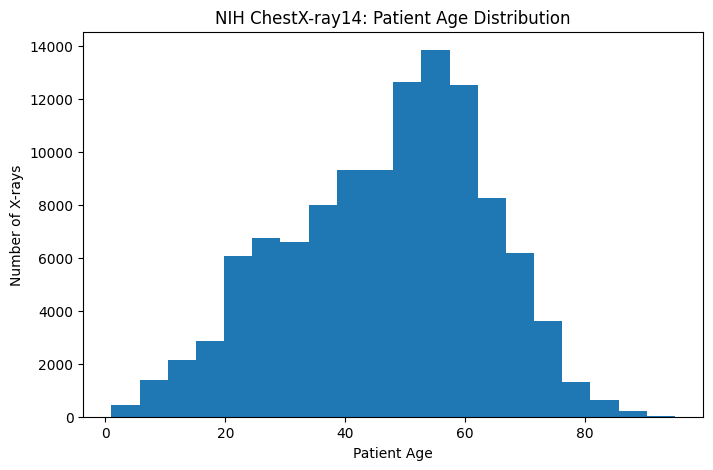

In [207]:
import matplotlib.pyplot as plt

age_data = df[df["Patient Age"] <= 100]

plt.figure(figsize=(8, 5))
plt.hist(age_data["Patient Age"], bins=20)
plt.title("NIH ChestX-ray14: Patient Age Distribution")
plt.xlabel("Patient Age")
plt.ylabel("Number of X-rays")
plt.show()

In [208]:
gender_counts = df["Patient Gender"].value_counts()

print(gender_counts)

Patient Gender
M    63340
F    48780
Name: count, dtype: int64


### Pneumonia Distribution by Gender

Cross-tabulation of pneumonia prevalence across gender groups.


In [209]:
pneumonia_by_gender = pd.crosstab(
    df["Patient Gender"],
    pneumonia_positive
)

print(pneumonia_by_gender)

Finding Labels  False  True 
Patient Gender              
F               48187    593
M               62502    838


### Pneumonia Distribution by Age Group

Patients are grouped into age bins (0–18, 19–40, 41–60, 61–80, 81–100) and pneumonia prevalence is examined per group. Invalid ages (> 100) are excluded here.


In [210]:
age_data = df[df["Patient Age"] <= 100].copy()

age_data["Age Group"] = pd.cut(
    age_data["Patient Age"],
    bins=[0, 18, 40, 60, 80, 100],
    labels=["0-18", "19-40", "41-60", "61-80", "81-100"]
)

pneumonia_by_age = pd.crosstab(
    age_data["Age Group"],
    age_data["Finding Labels"].str.contains(
        "Pneumonia",
        case=False,
        na=False
    )
)

print(pneumonia_by_age)

Finding Labels  False  True 
Age Group                   
0-18             5825    116
19-40           31547    467
41-60           48953    549
61-80           23478    288
81-100            871     10


---

## 8. Image Acquisition and View Analysis

Chest X-rays are acquired in different view positions:
- **PA (Posteroanterior)** – standard frontal view, patient faces the detector
- **AP (Anteroposterior)** – often used for bedridden patients

View position affects image appearance and may influence disease visibility, so we examine both the overall distribution and pneumonia prevalence by view.


In [211]:
view_counts = df["View Position"].value_counts()

print(view_counts)

View Position
PA    67310
AP    44810
Name: count, dtype: int64


### Pneumonia Distribution by View Position

Cross-tabulation of pneumonia prevalence across view positions.


In [212]:
pneumonia_by_view = pd.crosstab(
    df["View Position"],
    pneumonia_positive
)

print(pneumonia_by_view)

Finding Labels  False  True 
View Position               
AP              44009    801
PA              66680    630


---

## 9. Image Properties

We examine the technical properties of the X-ray images — dimensions (width/height) and pixel spacing. These properties determine the preprocessing (resizing, normalization) required for downstream analysis.


In [213]:
dimension_stats = df[["OriginalImage[Width", "Height]"]].describe()

print(dimension_stats)

       OriginalImage[Width        Height]
count        112120.000000  112120.000000
mean           2646.078844    2486.438842
std             341.246429     401.268227
min            1143.000000     966.000000
25%            2500.000000    2048.000000
50%            2518.000000    2544.000000
75%            2992.000000    2991.000000
max            3827.000000    4715.000000


### Image Dimension Distribution

Distribution of image widths and heights across the dataset.


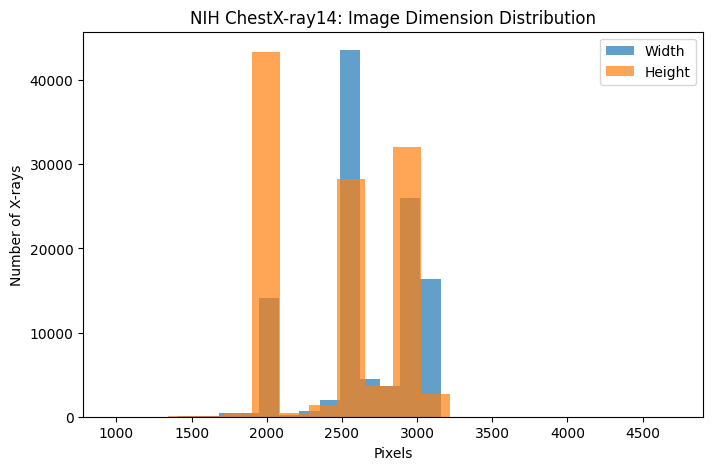

In [214]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df["OriginalImage[Width"], bins=20, alpha=0.7, label="Width")
plt.hist(df["Height]"], bins=20, alpha=0.7, label="Height")

plt.title("NIH ChestX-ray14: Image Dimension Distribution")
plt.xlabel("Pixels")
plt.ylabel("Number of X-rays")
plt.legend()
plt.show()

In [215]:
pixel_spacing_stats = df[[
    "OriginalImagePixelSpacing[x",
    "y]"
]].describe()

print(pixel_spacing_stats)

       OriginalImagePixelSpacing[x             y]
count                112120.000000  112120.000000
mean                      0.155649       0.155649
std                       0.016174       0.016174
min                       0.115000       0.115000
25%                       0.143000       0.143000
50%                       0.143000       0.143000
75%                       0.168000       0.168000
max                       0.198800       0.198800


### Pixel Spacing Distribution

Distribution of pixel spacing values (physical distance per pixel, in mm).


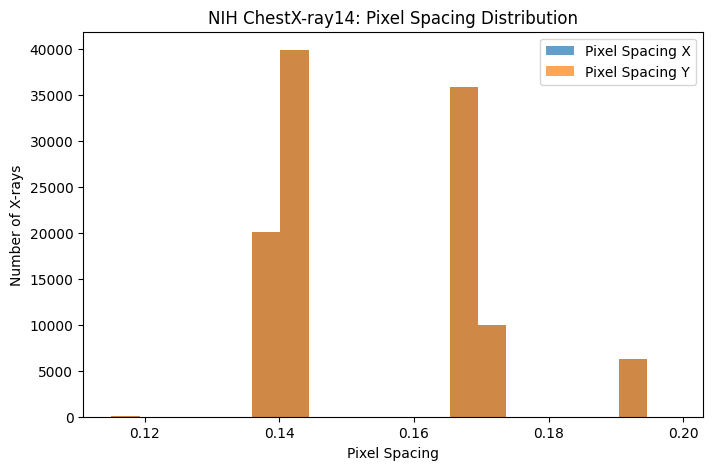

In [216]:
plt.figure(figsize=(8, 5))

plt.hist(df["OriginalImagePixelSpacing[x"], bins=20, alpha=0.7, label="Pixel Spacing X")
plt.hist(df["y]"], bins=20, alpha=0.7, label="Pixel Spacing Y")

plt.title("NIH ChestX-ray14: Pixel Spacing Distribution")
plt.xlabel("Pixel Spacing")
plt.ylabel("Number of X-rays")
plt.legend()
plt.show()

---

## 10. Data Quality and Key Observations

The observations below are all supported by the executed outputs above.

### 1. Class Imbalance
- Pneumonia prevalence is only **1.28%** (1,431 of 112,120 images)
- This is roughly a **77:1** negative-to-positive ratio
- Any downstream classifier must account for this imbalance (weighted loss, resampling)

### 2. Multi-Label Nature
- An image may carry several disease labels at once
- "No Finding" is the most common single label (60,361 images)
- "Pneumonia" appears in 1,431 images (alone or combined with other conditions)

### 3. Multiple Images per Patient
- 30,805 unique patients contribute 112,120 images (mean 3.64 images per patient)
- 75% of patients have 3 or fewer images; the maximum is 184
- **Critical:** train/test splits must be patient-level to avoid data leakage

### 4. Invalid Age Values
- 16 records have an age greater than 100 (ages 148 to 414)
- These are almost certainly data-entry errors
- The age-group analysis excludes them (age ≤ 100)

### 5. View Position
- PA views: 67,310 images (60.0%); AP views: 44,810 images (40.0%)
- Pneumonia is more frequent in AP views (801 cases) than in PA views (630 cases), despite AP having fewer total images

### 6. Image Properties
- Width ranges 1,143–3,827 px and height ranges 966–4,715 px
- Mean dimensions: approximately 2,646 × 2,486 pixels
- Pixel spacing ranges 0.115–0.199 mm (mean 0.156 mm)
- Standardization is required before model input

### 7. Metadata Artifact
- The column `Unnamed: 11` has 112,120 missing values and no useful content; it is a CSV parsing artifact and can be safely ignored


---

## 11. Final NIH Dataset Summary

The cell below prints a concise summary of the key statistics computed in this analysis. All values are taken from the existing calculations above.


In [217]:
nih_summary = {
    "Total X-rays": len(df),
    "Unique Patients": df["Patient ID"].nunique(),
    "Pneumonia Positive": pneumonia_positive.sum(),
    "Pneumonia Negative": (~pneumonia_positive).sum(),
    "Male": (df["Patient Gender"] == "M").sum(),
    "Female": (df["Patient Gender"] == "F").sum(),
    "PA Views": (df["View Position"] == "PA").sum(),
    "AP Views": (df["View Position"] == "AP").sum(),
    "Average Age": round(df["Patient Age"].mean(), 2),
    "Average Images per Patient": round(
        len(df) / df["Patient ID"].nunique(), 2
    )
}

for key, value in nih_summary.items():
    print(f"{key}: {value}")

Total X-rays: 112120
Unique Patients: 30805
Pneumonia Positive: 1431
Pneumonia Negative: 110689
Male: 63340
Female: 48780
PA Views: 67310
AP Views: 44810
Average Age: 46.9
Average Images per Patient: 3.64


---

## 12. Conclusion

This exploratory analysis of the NIH ChestX-ray14 dataset established the following:

1. **Scale:** 112,120 X-ray images from 30,805 unique patients — one of the largest public chest X-ray datasets.
2. **Class imbalance:** Pneumonia appears in only 1.28% of images (1,431 of 112,120), a severe imbalance that must be handled during classification.
3. **Multi-label structure:** Images frequently carry multiple disease labels, and "No Finding" is the most common annotation.
4. **Patient-level structure:** Images cluster by patient (mean 3.64, max 184 images per patient), so patient-level splitting is required to avoid data leakage.
5. **Demographics:** Patients span ages 1 to 100+ (median 49), with 63,340 male and 48,780 female images, giving a demographically broad cohort.
6. **Image variability:** Dimensions (1,143–3,827 × 966–4,715 px) and pixel spacing (0.115–0.199 mm) vary substantially, requiring standardized preprocessing.
7. **Data quality:** 16 records contain invalid ages (> 100), and one empty artifact column (`Unnamed: 11`) is present.

Together, these characteristics define the NIH ChestX-ray14 domain and provide the reference point for the cross-domain comparison that follows.


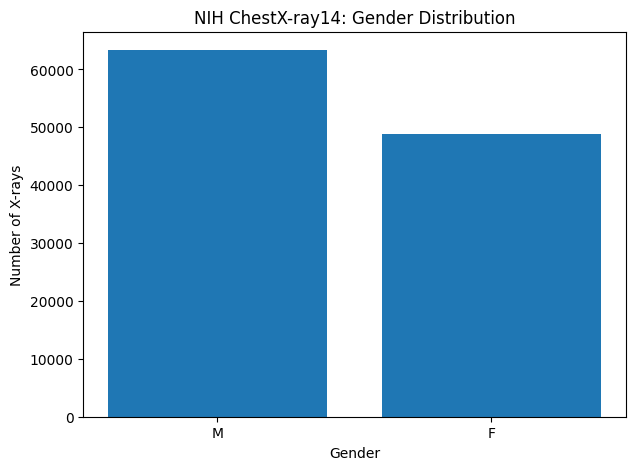

In [218]:
import matplotlib.pyplot as plt

gender_counts = df["Patient Gender"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(gender_counts.index, gender_counts.values)

plt.title("NIH ChestX-ray14: Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of X-rays")

plt.show()